## First order ODEs
Following the work of Mr. P Solver on [differential equations](https://github.com/lukepolson/youtube_channel/blob/main/Python%20Tutorial%20Series/odes1.ipynb)

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy.integrate import odeint # Integrate a system of ordinary differential equations.
from scipy.integrate import solve_ivp # Solve a boundary value problem for a system of ODEs.

## Air friction while falling
$$
    \text{Formula: } \frac{dv}{dt} - \alpha v^2 + \beta = 0, \qquad \text{initial condition; } v(0) = 0
$$
where $v(0)$; initial velocity, $\alpha$; air resistance (constant for now), $\beta$; constant.

1. step: we need to write this in the form:
$$
    \frac{dv}{dt} = f(t, v)
$$
function $f(t, v)$ deals with both $\alpha$ and $\beta$, this tells that; "derivative of $v$ equals something that depends $v$ and $t$ (time)". It is clear that:
$$
    \frac{dv}{dt} = \alpha v^2 - \beta
$$


In [2]:
# Writing dv/dt = αv^2 - β; α = 3, β = 5
def dvdt(t, v):
    return 3*v**2 - 5
v0 = 0

Solve differential equation. There are two main solvers in scipy
* `odeint`: Uses a particular solve called Isoda from the FORTRAN library odepack
* `solve_ivp`: More customizable, can choose from a list of possible solvers

First, use `linspace` (generate an array of evenly spaced numbers over a specified interval) on $t$; time and create an evenly spaced map of it: 

In [5]:
t = np.linspace(0, 1, 100)
t

array([0.        , 0.01010101, 0.02020202, 0.03030303, 0.04040404,
       0.05050505, 0.06060606, 0.07070707, 0.08080808, 0.09090909,
       0.1010101 , 0.11111111, 0.12121212, 0.13131313, 0.14141414,
       0.15151515, 0.16161616, 0.17171717, 0.18181818, 0.19191919,
       0.2020202 , 0.21212121, 0.22222222, 0.23232323, 0.24242424,
       0.25252525, 0.26262626, 0.27272727, 0.28282828, 0.29292929,
       0.3030303 , 0.31313131, 0.32323232, 0.33333333, 0.34343434,
       0.35353535, 0.36363636, 0.37373737, 0.38383838, 0.39393939,
       0.4040404 , 0.41414141, 0.42424242, 0.43434343, 0.44444444,
       0.45454545, 0.46464646, 0.47474747, 0.48484848, 0.49494949,
       0.50505051, 0.51515152, 0.52525253, 0.53535354, 0.54545455,
       0.55555556, 0.56565657, 0.57575758, 0.58585859, 0.5959596 ,
       0.60606061, 0.61616162, 0.62626263, 0.63636364, 0.64646465,
       0.65656566, 0.66666667, 0.67676768, 0.68686869, 0.6969697 ,
       0.70707071, 0.71717172, 0.72727273, 0.73737374, 0.74747

Then, check the solution by `odeint` and `solve_ivp`

In [10]:
sol_m1 = odeint(dvdt, y0=v0, t=t, tfirst=True)
sol_m2 = solve_ivp(dvdt, t_span=(0, max(t)), y0=[v0], t_eval=t)

In [11]:
sol_m1

array([[ 0.        ],
       [-0.05047933],
       [-0.10080451],
       [-0.15082334],
       [-0.20038726],
       [-0.24935318],
       [-0.29758502],
       [-0.34495519],
       [-0.39134576],
       [-0.43664948],
       [-0.48077056],
       [-0.52362515],
       [-0.56514164],
       [-0.60526086],
       [-0.6439356 ],
       [-0.68113064],
       [-0.71682205],
       [-0.75099661],
       [-0.78365109],
       [-0.8147914 ],
       [-0.84443176],
       [-0.87259378],
       [-0.89930556],
       [-0.92460079],
       [-0.94851787],
       [-0.97109913],
       [-0.99239002],
       [-1.01243837],
       [-1.03129376],
       [-1.04900692],
       [-1.06562918],
       [-1.081212  ],
       [-1.0958066 ],
       [-1.10946355],
       [-1.12223249],
       [-1.13416195],
       [-1.14529906],
       [-1.15568941],
       [-1.16537698],
       [-1.17440397],
       [-1.18281086],
       [-1.19063623],
       [-1.19791686],
       [-1.20468768],
       [-1.21098179],
       [-1

In [12]:
sol_m2

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.010e-02 ...  9.899e-01  1.000e+00]
        y: [[ 0.000e+00 -5.048e-02 ... -1.290e+00 -1.290e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 68
     njev: 0
      nlu: 0

Looking at solutions.

In [15]:
v_sol_m1 = sol_m1.T[0]
v_sol_m2 = sol_m2.y[0]

In [28]:
v_sol_m1

array([ 0.        , -0.05047933, -0.10080451, -0.15082334, -0.20038726,
       -0.24935318, -0.29758502, -0.34495519, -0.39134576, -0.43664948,
       -0.48077056, -0.52362515, -0.56514164, -0.60526086, -0.6439356 ,
       -0.68113064, -0.71682205, -0.75099661, -0.78365109, -0.8147914 ,
       -0.84443176, -0.87259378, -0.89930556, -0.92460079, -0.94851787,
       -0.97109913, -0.99239002, -1.01243837, -1.03129376, -1.04900692,
       -1.06562918, -1.081212  , -1.0958066 , -1.10946355, -1.12223249,
       -1.13416195, -1.14529906, -1.15568941, -1.16537698, -1.17440397,
       -1.18281086, -1.19063623, -1.19791686, -1.20468768, -1.21098179,
       -1.21683053, -1.22226349, -1.22730856, -1.23199199, -1.23633849,
       -1.24037122, -1.24411192, -1.24758094, -1.25079735, -1.25377896,
       -1.25654241, -1.25910322, -1.2614759 , -1.26367394, -1.26570992,
       -1.26759557, -1.26934179, -1.27095869, -1.27245574, -1.27384168,
       -1.27512464, -1.2763122 , -1.27741137, -1.27842865, -1.27

In [29]:
v_sol_m2

array([ 0.        , -0.0504793 , -0.10080722, -0.15083038, -0.20039553,
       -0.24935878, -0.29758564, -0.34495103, -0.39133929, -0.43664418,
       -0.48076886, -0.52362591, -0.56513507, -0.60524282, -0.64391404,
       -0.68112062, -0.71684143, -0.75106235, -0.78377623, -0.81498294,
       -0.84468932, -0.87290923, -0.89966349, -0.92497994, -0.94889341,
       -0.97144571, -0.99268566, -1.01266906, -1.03145871, -1.04912441,
       -1.06573928, -1.08134937, -1.09599363, -1.10971235, -1.12254598,
       -1.13453506, -1.14572027, -1.15614242, -1.16584241, -1.17486131,
       -1.18324028, -1.19102062, -1.19824374, -1.20495119, -1.21118463,
       -1.21698585, -1.22239666, -1.22744653, -1.23215067, -1.23652537,
       -1.24058697, -1.24435186, -1.24783652, -1.25105747, -1.25403128,
       -1.25677462, -1.25930417, -1.2616367 , -1.26378904, -1.26577807,
       -1.26762074, -1.26933406, -1.27093508, -1.27243817, -1.27384571,
       -1.27515955, -1.27638204, -1.27751582, -1.27856386, -1.27

Plot

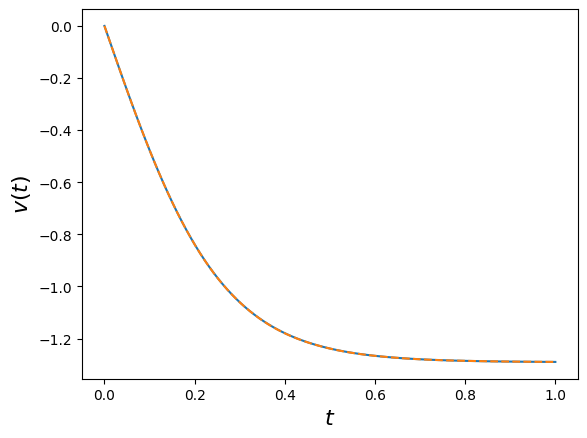

In [17]:
plt.plot(t, v_sol_m1)
plt.plot(t, v_sol_m2, '--')
plt.ylabel('$v(t)$', fontsize=16)
plt.xlabel('$t$', fontsize=16)
plt.show()

## Coupled first order ODEs
$$
    \begin{align}
        y'_1 &= y_1 + y_2^2 + 3x, \qquad y_1(0) = 0 \\
        y'_2 &= 3y_1 + y_2^3 + \cos{(x)}, \qquad y_2(0) = 0
    \end{align}
$$
Say $S=(y_1, y_2)$ we need to write a function that gives: $dS/dx = (dy_1/dx, dy_2/dx)$. Then, function $dS/dx$ can take in $S = (y_1, y_2)$ and $x$:
$$
    \vec{S} = \begin{bmatrix} y_1 \\ y_2 \end{bmatrix} \Rightarrow \frac{d\vec{S}}{dx} = \vec{f}(x, \vec{S}) = \vec{f}(x, y_1, y_2) = \begin{bmatrix} y'_1 \\ y'_2 \end{bmatrix} = \begin{bmatrix} y_1 + y_2^2 + 3x \\ y_1 + y_2^3 - \cos{(x)} \end{bmatrix}
$$
    Note: $x$ here is the independent variable of the ODE (it was $t$ in the first example ODE)

In [ ]:
# Take S function by y_1 and y_2
# Return dSdx which is y'_1 and y'_2
def dSdx(x, S):
    y1, y2 = S 
    return [y1 + y2**2 + 3*x,
            y1 + y2**3 - np.cos(x)]

# Initial conditions
y1_0 = 0
y2_0 = 0
S_0 = (y1_0, y2_0)

Solve this ODE

In [31]:
x = np.linspace(0, 1, 100)
sol = odeint(dSdx, y0=S_0, t=x, tfirst=True) # t=x variable is x

In [32]:
sol

array([[ 0.00000000e+00,  0.00000000e+00],
       [ 1.53921693e-04, -1.01003114e-02],
       [ 6.19102354e-04, -2.01965182e-02],
       [ 1.40078449e-03, -3.02845010e-02],
       [ 2.50424168e-03, -4.03601612e-02],
       [ 3.93479127e-03, -5.04194084e-02],
       [ 5.69779203e-03, -6.04581595e-02],
       [ 7.79863960e-03, -7.04723363e-02],
       [ 1.02427640e-02, -8.04578646e-02],
       [ 1.30356270e-02, -9.04106729e-02],
       [ 1.61827201e-02, -1.00326688e-01],
       [ 1.96895605e-02, -1.10201837e-01],
       [ 2.35616884e-02, -1.20032039e-01],
       [ 2.78046643e-02, -1.29813209e-01],
       [ 3.24240659e-02, -1.39541250e-01],
       [ 3.74254849e-02, -1.49212052e-01],
       [ 4.28145246e-02, -1.58821489e-01],
       [ 4.85967964e-02, -1.68365416e-01],
       [ 5.47779171e-02, -1.77839663e-01],
       [ 6.13635060e-02, -1.87240035e-01],
       [ 6.83591817e-02, -1.96562306e-01],
       [ 7.57705590e-02, -2.05802214e-01],
       [ 8.36032463e-02, -2.14955461e-01],
       [ 9.

Get **$y_1$** and **$y_2$** from the solution

In [20]:
y1_sol = sol.T[0]
y2_sol = sol.T[1]

In [22]:
y1_sol

array([0.00000000e+00, 1.53921693e-04, 6.19102354e-04, 1.40078449e-03,
       2.50424168e-03, 3.93479127e-03, 5.69779203e-03, 7.79863960e-03,
       1.02427640e-02, 1.30356270e-02, 1.61827201e-02, 1.96895605e-02,
       2.35616884e-02, 2.78046643e-02, 3.24240659e-02, 3.74254849e-02,
       4.28145246e-02, 4.85967964e-02, 5.47779171e-02, 6.13635060e-02,
       6.83591817e-02, 7.57705590e-02, 8.36032463e-02, 9.18628424e-02,
       1.00554933e-01, 1.09685090e-01, 1.19258862e-01, 1.29281781e-01,
       1.39759350e-01, 1.50697047e-01, 1.62100316e-01, 1.73974569e-01,
       1.86325180e-01, 1.99157482e-01, 2.12476764e-01, 2.26288269e-01,
       2.40597190e-01, 2.55408668e-01, 2.70727786e-01, 2.86559570e-01,
       3.02908981e-01, 3.19780919e-01, 3.37180213e-01, 3.55111623e-01,
       3.73579834e-01, 3.92589457e-01, 4.12145022e-01, 4.32250981e-01,
       4.52911700e-01, 4.74131461e-01, 4.95914461e-01, 5.18264805e-01,
       5.41186510e-01, 5.64683501e-01, 5.88759613e-01, 6.13418589e-01,
      

In [23]:
y2_sol

array([ 0.        , -0.01010031, -0.02019652, -0.0302845 , -0.04036016,
       -0.05041941, -0.06045816, -0.07047234, -0.08045786, -0.09041067,
       -0.10032669, -0.11020184, -0.12003204, -0.12981321, -0.13954125,
       -0.14921205, -0.15882149, -0.16836542, -0.17783966, -0.18724004,
       -0.19656231, -0.20580221, -0.21495546, -0.22401771, -0.23298456,
       -0.24185159, -0.25061429, -0.25926811, -0.26780842, -0.27623054,
       -0.2845297 , -0.29270105, -0.30073968, -0.30864055, -0.31639857,
       -0.32400852, -0.33146509, -0.33876286, -0.34589631, -0.35285977,
       -0.35964748, -0.36625354, -0.37267194, -0.3788965 , -0.38492094,
       -0.3907388 , -0.39634353, -0.40172838, -0.40688648, -0.41181079,
       -0.41649415, -0.42092921, -0.42510848, -0.42902432, -0.43266893,
       -0.43603435, -0.43911248, -0.44189506, -0.4443737 , -0.44653984,
       -0.44838482, -0.44989982, -0.45107589, -0.451904  , -0.45237497,
       -0.45247955, -0.45220838, -0.45155203, -0.45050102, -0.44

Plot

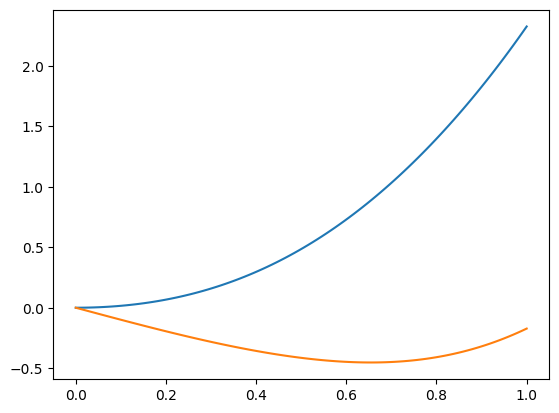

In [21]:
plt.plot(x, y1_sol)
plt.plot(x, y2_sol)

## Second order ODEs
**Python does not have functions to directly solve second order ODEs.**
* But **any second order ODE can be converted into two first order ODEs.**

Consider second order ODE:
$$
    \ddot{x} = -\dot{x}^2 + \sin{(x)}
$$
We can conver this into two first order ODEs as:
* Take $x$ (which is what we are trying to solve for), then define $\dot{x} = v$ so that $v$ becomes a new variable.
* Note that $\dot{x} = V$ is one differential equation.
* Since $\dot{v} = \ddot{x} = -\dot{x}^2 + \sin{(x)} = -v^2 + \sin{(x)}$ we get another differential equation.

Our two equations now:
$$
    \begin{align}
        \dot{x} &= v\\
        \dot{v} &= -v^2 + \sin{(x)}
    \end{align}
$$
This are two coupled first order equations. They require an initial condition ($x_0$ and $y_0$).


In [33]:
# Take S function with x, v
# Return dSdx

def dSdx(x, S):
    x, v = S
    return[v,
           -v**2 + np.sin(x)]

# Initial conditions
x_0 = 0
v_0 = 5
S_0 = (x_0, v_0)

In [34]:
t = np.linspace(0, 1, 100) # bot x and v changes by t
sol = odeint(dSdx, y0=S_0, t=t, tfirst=True)

In [35]:
sol

array([[0.        , 5.        ],
       [0.04927187, 4.75985831],
       [0.09623442, 4.54221181],
       [0.14109945, 4.34410199],
       [0.18405151, 4.16306776],
       [0.22525234, 3.99704524],
       [0.26484454, 3.84429058],
       [0.30295443, 3.7033201 ],
       [0.33969447, 3.57286357],
       [0.37516519, 3.45182697],
       [0.40945686, 3.33926295],
       [0.44265079, 3.23434698],
       [0.47482052, 3.13635808],
       [0.50603274, 3.04466299],
       [0.53634816, 2.95870318],
       [0.56582216, 2.87798414],
       [0.59450542, 2.80206643],
       [0.62244441, 2.73055821],
       [0.64968187, 2.66310892],
       [0.67625719, 2.59940399],
       [0.70220674, 2.53916033],
       [0.72756415, 2.48212244],
       [0.75236064, 2.42805915],
       [0.77662516, 2.37676077],
       [0.80038467, 2.32803661],
       [0.82366429, 2.28171293],
       [0.84648743, 2.23763104],
       [0.86887601, 2.1956457 ],
       [0.89085052, 2.15562374],
       [0.91243016, 2.11744282],
       [0.

Solutions

In [40]:
x_sol = sol.T[0] # left column of sol
v_sol = sol.T[1] # right column of sol

In [38]:
x_sol

array([0.        , 0.04927187, 0.09623442, 0.14109945, 0.18405151,
       0.22525234, 0.26484454, 0.30295443, 0.33969447, 0.37516519,
       0.40945686, 0.44265079, 0.47482052, 0.50603274, 0.53634816,
       0.56582216, 0.59450542, 0.62244441, 0.64968187, 0.67625719,
       0.70220674, 0.72756415, 0.75236064, 0.77662516, 0.80038467,
       0.82366429, 0.84648743, 0.86887601, 0.89085052, 0.91243016,
       0.93363296, 0.95447584, 0.97497472, 0.99514459, 1.01499958,
       1.034553  , 1.05381745, 1.07280482, 1.09152635, 1.1099927 ,
       1.12821396, 1.1461997 , 1.163959  , 1.18150047, 1.19883232,
       1.21596233, 1.23289791, 1.24964611, 1.26621365, 1.28260693,
       1.29883205, 1.31489483, 1.33080083, 1.34655534, 1.36216343,
       1.37762994, 1.39295949, 1.4081565 , 1.4232252 , 1.43816962,
       1.45299365, 1.46770098, 1.48229515, 1.49677957, 1.51115749,
       1.52543202, 1.53960614, 1.55368273, 1.56766451, 1.58155413,
       1.59535409, 1.60906682, 1.62269463, 1.63623974, 1.64970

In [39]:
v_sol

array([5.        , 4.75985831, 4.54221181, 4.34410199, 4.16306776,
       3.99704524, 3.84429058, 3.7033201 , 3.57286357, 3.45182697,
       3.33926295, 3.23434698, 3.13635808, 3.04466299, 2.95870318,
       2.87798414, 2.80206643, 2.73055821, 2.66310892, 2.59940399,
       2.53916033, 2.48212244, 2.42805915, 2.37676077, 2.32803661,
       2.28171293, 2.23763104, 2.1956457 , 2.15562374, 2.11744282,
       2.08099032, 2.04616243, 2.01286324, 1.98100407, 1.95050274,
       1.92128301, 1.89327403, 1.86640988, 1.84062917, 1.81587458,
       1.79209263, 1.76923325, 1.74724961, 1.72609778, 1.70573656,
       1.68612725, 1.66723346, 1.64902094, 1.63145742, 1.61451248,
       1.5981574 , 1.58236506, 1.56710982, 1.55236741, 1.53811486,
       1.52433039, 1.51099337, 1.49808418, 1.48558423, 1.47347582,
       1.46174213, 1.45036716, 1.43933567, 1.42863313, 1.41824569,
       1.40816016, 1.39836393, 1.38884496, 1.37959176, 1.37059333,
       1.36183916, 1.35331919, 1.34502379, 1.33694375, 1.32907

Plot

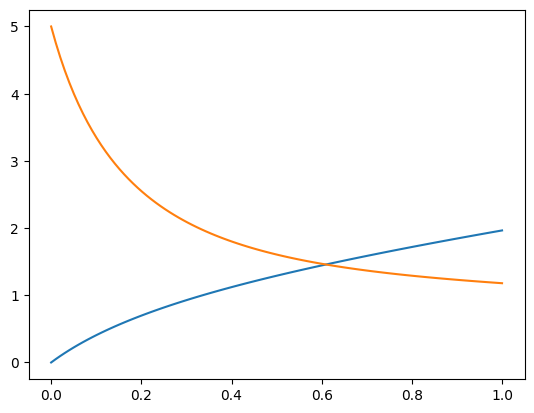

In [41]:
plt.plot(t, x_sol)
plt.plot(t, v_sol)

## Two coupled third order ODE
Example:
$$
    \begin{align}
        \dddot{x}_2 &= -\ddot{x}_1^3 + \dot{x_2} + x_1 + \sin{(t)}\\
        \dddot{x}_1 &= -2\dot{x}_2^2 + x_2
    \end{align}
$$
Arrangements:
* $v_1 = \dot{x}_1$ 
* $v_2 = \dot{x}_2$ 
* $a_1 = \ddot{x}_1 = \dot{v}_1$ 
* $v_1 = \ddot{x}_2 = \dot{v}_2$ 

These are settled for up to $4$ differential equations. Accordingly:
* $\dot{a}_2 = \dddot{x}_1 = -a_1^3 + v_2 + x_1 + \sin{(t)}$
* $\dot{a}_1 = -2v_2^2 + x_2$

Then:
$$
    \vec{S} = \begin{bmatrix} x_1 \\ v_1 \\ a_1 \\ x_2 \\ v_2 \\ a_2 \end{bmatrix} \Rightarrow \frac{d\vec{S}}{dt} = \begin{bmatrix} \dot{x}_1 \\ \dot{v}_1 \\ \dot{a}_1 \\ \dot{x}_2 \\ \dot{v}_2 \\ \dot{a}_2 \end{bmatrix} = \begin{bmatrix} v_1 \\ a_1 \\ -2v_2^2 + x_2 \\ v_2 \\ a_2 \\ -a_1^3 + v_2 + x_1 + \sin{(t)} \end{bmatrix}
$$
Defining function for ODEs

In [49]:
# Take function with x_1, v_1, a_1, x_2, v_2, a_2
# Return dSdt
def dSdt(t, S):
    x1, v1, a1, x2, v2, a2 = S
    return[v1,
           a1,
           -2*v2**2 + x2,
           v2,
           a2,
           -a1**3 + v2 + x1 + np.sin(t)]

# Initial conditions
x1_0 = 0
v1_0 = 0
a1_0 = 0
x2_0 = 0
v2_0 = 0
a2_0 = 0
v_0 = 0
S_0 = (x1_0, v1_0, a1_0, x2_0, v2_0, a2_0)

In [50]:
t = np.linspace(0, 1, 100)
sol = odeint(dSdt, y0=S_0, t=t, tfirst=True)

In [51]:
sol

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [1.94774155e-18, 2.07655671e-15, 1.18358922e-12, 5.63295114e-10,
        1.84150565e-07, 5.10152722e-05],
       [5.14534641e-16, 1.55729336e-13, 3.86496253e-11, 7.72511766e-09,
        1.37105625e-06, 2.04061002e-04],
       [5.51566388e-15, 1.27192658e-12, 2.43143651e-10, 3.64960973e-08,
        4.62675579e-06, 4.59136929e-04],
       [3.69137037e-14, 6.63448493e-12, 9.71247706e-10, 1.13105972e-07,
        1.09821887e-05, 8.16243224e-04],
       [1.94444644e-13, 2.58326270e-11, 2.92062908e-09, 2.75033792e-07,
        2.14600640e-05, 1.27537995e-03],
       [6.43797425e-13, 7.30884860e-11, 7.01696477e-09, 5.65949423e-07,
        3.70909811e-05, 1.83654712e-03],
       [1.89189192e-12, 1.81845977e-10, 1.49765349e-08, 1.04552451e-06,
        5.89055591e-05, 2.49974475e-03],
       [4.84412970e-12, 4.03751311e-10, 2.90223745e-08, 1.78062809e-06,
        8.79344042e-05, 

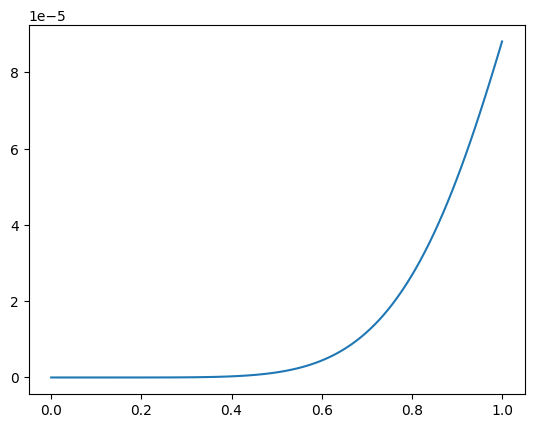

In [57]:
plt.plot(t, sol.T[0])

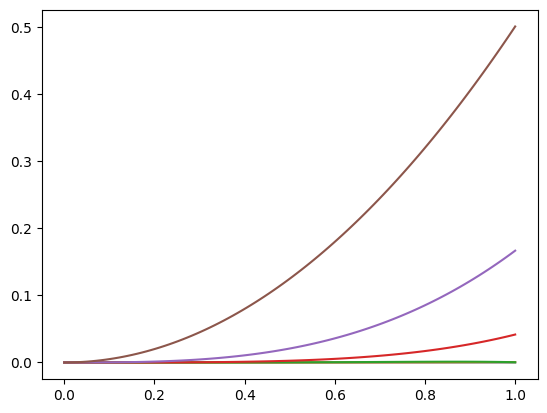

In [56]:
plt.plot(t, sol.T[0])
plt.plot(t, sol.T[1])
plt.plot(t, sol.T[2])
plt.plot(t, sol.T[3])
plt.plot(t, sol.T[4])
plt.plot(t, sol.T[5])

## A Final Note: Be Careful
Not all solvers work for all ODEs. For example, the ODEs for 3 body motion
* $dy_1/dt = v_{y1}$
* $dx_2/dt = v_{x2}$
* $dy_2/dt = v_{y2}$
* $dx_3/dt = v_{x3}$
* $dy_3/dt = v_{y3}$
* $dv_{x1}/dt = \frac{x_2-x_1}{\sqrt{(x_2-x_1)^2+(y_2-y_1)^2}} + \frac{x_3-x_1}{\sqrt{(x_3-x_1)^2+(y_3-y_1)^2}}$
* $dv_{y1}/dt = \frac{y_2-y_1}{\sqrt{(x_2-x_1)^2+(y_2-y_1)^2}} + \frac{y_3-y_1}{\sqrt{(x_3-x_1)^2+(y_3-y_1)^2}}$
* $dv_{x2}/dt = \frac{x_1-x_2}{\sqrt{(x_2-x_1)^2+(y_2-y_1)^2}} + \frac{x_3-x_2}{\sqrt{(x_3-x_1)^2+(y_3-y_1)^2}}$
* $dv_{y2}/dt = \frac{y_1-y_2}{\sqrt{(x_2-x_1)^2+(y_2-y_1)^2}} + \frac{y_3-x_2}{\sqrt{(x_3-x_1)^2+(y_3-y_1)^2}}$
* $dv_{x3}/dt = \frac{x_1-x_3}{\sqrt{(x_2-x_1)^2+(y_2-y_1)^2}} + \frac{x_2-x_3}{\sqrt{(x_3-x_1)^2+(y_3-y_1)^2}}$
* $dv_{y3}/dt = \frac{y_1-y_3}{\sqrt{(x_2-x_1)^2+(y_2-y_1)^2}} + \frac{y_2-y_3}{\sqrt{(x_3-x_1)^2+(y_3-y_1)^2}}$

Require the DOP853 (Explicit Runge-Kutta method of order 8: https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html) solver with low values for `rtol` (relative tolerance) and `atol` (absolute tolerance) (https://numpy.org/doc/stable/reference/generated/numpy.allclose.html) to solve (https://arxiv.org/pdf/1709.04775.pdf).

Always review the literature on your specific ODE to find an appropriate solver. In addition, play around with the parameters `rtol` and `atol` to ensure you get a proper solution.

Defining function:

In [58]:
def dSdt(t, S):
    x1, y1, x2, y2, x3, y3, vx1, vy1, vx2, vy2, vx3, vy3 = S
    r12 = np.sqrt((x2-x1)**2 + (y2-y1)**2)
    r13 = np.sqrt((x3-x1)**2 + (y3-y1)**2)
    r23 = np.sqrt((x2-x3)**2 + (y2-y3)**2)
    return [ vx1,
            vy1,
            vx2,
            vy2,
            vx3,
            vy3,
            1/r12**3 * (x2-x1) + 1/r13**3 * (x3-x1), #mass 1
            1/r12**3 * (y2-y1) + 1/r13**3 * (y3-y1),
            1/r12**3 * (x1-x2) + 1/r23**3 * (x3-x2), #mass 2
            1/r12**3 * (y1-y2) + 1/r23**3 * (y3-y2),
            1/r13**3 * (x1-x3) + 1/r23**3 * (x2-x3), #mass 3
            1/r13**3 * (y1-y3) + 1/r23**3 * (y2-y3)
           ]

Initial conditions:

In [ ]:
v1 = 0.39295
v2 = 0.09758

x1_0 = -1
y1_0 = 0
x2_0 = 1
y2_0 = 0
x3_0 = 0
y3_0 = 0
vx1_0 =  v1
vy1_0 =  v2
vx2_0 = v1
vy2_0 = v2
vx3_0 = -2*v1
vy3_0 = -2*v2

Solve

In [68]:
t = np.linspace(0, 40, 1000)
sol = solve_ivp(dSdt, (0,40), y0=[x1_0, y1_0, x2_0, y2_0, x3_0, y3_0, 
                       vx1_0, vy1_0, vx2_0, vy2_0, vx3_0, vy3_0], method='DOP853', t_eval=t, rtol=1e-10, atol=1e-13)


In [69]:
sol

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  4.004e-02 ...  3.996e+01  4.000e+01]
        y: [[-1.000e+00 -9.832e-01 ... -1.025e+00 -1.019e+00]
            [ 0.000e+00  3.904e-03 ...  2.648e-02  2.463e-02]
            ...
            [-7.859e-01 -7.897e-01 ... -1.323e+00 -1.170e+00]
            [-1.952e-01 -1.947e-01 ... -3.309e-01 -2.583e-01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 84542
     njev: 0
      nlu: 0

Get solutions

In [70]:
t = sol.t
x1 = sol.y[0]
y1 = sol.y[1]
x2 = sol.y[2]
y2 = sol.y[3]
x3 = sol.y[4]
y3 = sol.y[5]

Plot

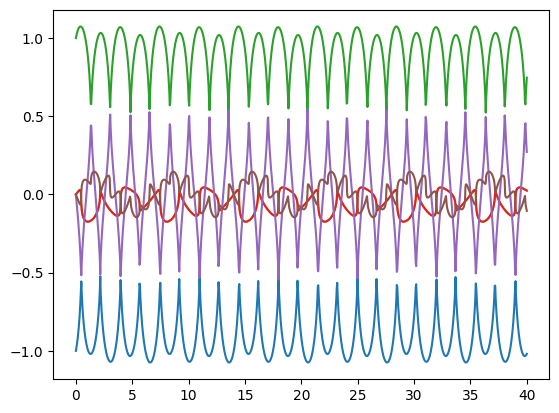

In [71]:
plt.plot(t, x1)
plt.plot(t, y1)
plt.plot(t, x2)
plt.plot(t, y1)
plt.plot(t, x3)
plt.plot(t, y3)
